# Yolo V7

----

Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)

----

- Ref: 
    - https://docs.ultralytics.com/models/yolov7/#usage-examples

### Download pre-trained yolo7 model

In [1]:
import utils
yolo7_url = "https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt"
down_dir = "./temp/models"
utils.download_file(url = yolo7_url, destination_folder= down_dir)

File 'yolov7.pt' downloaded successfully to '/home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp/models/yolov7.pt'


### Convert the downloaded pt file to onnx file

In [2]:
!git clone git@github.com:hyunjaeKang/yolov7.git temp_yolov7
# cd yolov7
# python export.py --weights yolov7-tiny.pt --grid --end2end --simplify --topk-all 100 --iou-thres 0.65 --conf-thres 0.35 --img-size 640 640 --max-wh 640

fatal: destination path 'temp_yolov7' already exists and is not an empty directory.


In [3]:
!python temp_yolov7/export.py --weights ./temp/models/yolov7.pt --grid --end2end --simplify --topk-all 100 --iou-thres 0.65 --conf-thres 0.35 --img-size 640 640 --max-wh 640

Namespace(weights='./temp/models/yolov7.pt', img_size=[640, 640], batch_size=1, dynamic=False, dynamic_batch=False, grid=True, end2end=True, max_wh=640, topk_all=100, iou_thres=0.65, conf_thres=0.35, device='cpu', simplify=True, include_nms=False, fp16=False, int8=False)
YOLOR 🚀 a207844 torch 2.8.0+cu128 CPU

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
/home/hyunjae/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Model Summary: 306 layers, 36905341 parameters, 36905341 gradients, 104.5 GFLOPS

Starting TorchScript export with torch 2.8.0+cu128...
/home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_yolov7/models/yolo.py:52: Tra

### Update the ONNX model graph to be compatible with Ultralytics 

In [4]:
import numpy as np
import onnx
from onnx import helper, numpy_helper

# Load the ONNX model
model_path = "./temp/models/yolov7.onnx"  # Replace with your model path
model = onnx.load(model_path)
graph = model.graph

# Fix input shape to batch size 1
input_shape = graph.input[0].type.tensor_type.shape
input_shape.dim[0].dim_value = 1

# Define the output of the original model
original_output_name = graph.output[0].name

# Create slicing nodes
sliced_output_name = f"{original_output_name}_sliced"

# Define initializers for slicing (remove the first value)
start = numpy_helper.from_array(np.array([1], dtype=np.int64), name="slice_start")
end = numpy_helper.from_array(np.array([7], dtype=np.int64), name="slice_end")
axes = numpy_helper.from_array(np.array([1], dtype=np.int64), name="slice_axes")
steps = numpy_helper.from_array(np.array([1], dtype=np.int64), name="slice_steps")

graph.initializer.extend([start, end, axes, steps])

slice_node = helper.make_node(
    "Slice",
    inputs=[original_output_name, "slice_start", "slice_end", "slice_axes", "slice_steps"],
    outputs=[sliced_output_name],
    name="SliceNode",
)
graph.node.append(slice_node)

# Define segment slicing
seg1_start = numpy_helper.from_array(np.array([0], dtype=np.int64), name="seg1_start")
seg1_end = numpy_helper.from_array(np.array([4], dtype=np.int64), name="seg1_end")
seg2_start = numpy_helper.from_array(np.array([4], dtype=np.int64), name="seg2_start")
seg2_end = numpy_helper.from_array(np.array([5], dtype=np.int64), name="seg2_end")
seg3_start = numpy_helper.from_array(np.array([5], dtype=np.int64), name="seg3_start")
seg3_end = numpy_helper.from_array(np.array([6], dtype=np.int64), name="seg3_end")

graph.initializer.extend([seg1_start, seg1_end, seg2_start, seg2_end, seg3_start, seg3_end])

# Create intermediate tensors for segments
segment_1_name = f"{sliced_output_name}_segment1"
segment_2_name = f"{sliced_output_name}_segment2"
segment_3_name = f"{sliced_output_name}_segment3"

# Add segment slicing nodes
graph.node.extend(
    [
        helper.make_node(
            "Slice",
            inputs=[sliced_output_name, "seg1_start", "seg1_end", "slice_axes", "slice_steps"],
            outputs=[segment_1_name],
            name="SliceSegment1",
        ),
        helper.make_node(
            "Slice",
            inputs=[sliced_output_name, "seg2_start", "seg2_end", "slice_axes", "slice_steps"],
            outputs=[segment_2_name],
            name="SliceSegment2",
        ),
        helper.make_node(
            "Slice",
            inputs=[sliced_output_name, "seg3_start", "seg3_end", "slice_axes", "slice_steps"],
            outputs=[segment_3_name],
            name="SliceSegment3",
        ),
    ]
)

# Concatenate the segments
concat_output_name = f"{sliced_output_name}_concat"
concat_node = helper.make_node(
    "Concat",
    inputs=[segment_1_name, segment_3_name, segment_2_name],
    outputs=[concat_output_name],
    axis=1,
    name="ConcatSwapped",
)
graph.node.append(concat_node)

# Reshape to [1, -1, 6]
reshape_shape = numpy_helper.from_array(np.array([1, -1, 6], dtype=np.int64), name="reshape_shape")
graph.initializer.append(reshape_shape)

final_output_name = f"{concat_output_name}_batched"
reshape_node = helper.make_node(
    "Reshape",
    inputs=[concat_output_name, "reshape_shape"],
    outputs=[final_output_name],
    name="AddBatchDimension",
)
graph.node.append(reshape_node)

# Get the shape of the reshaped tensor
shape_node_name = f"{final_output_name}_shape"
shape_node = helper.make_node(
    "Shape",
    inputs=[final_output_name],
    outputs=[shape_node_name],
    name="GetShapeDim",
)
graph.node.append(shape_node)

# Extract the second dimension
dim_1_index = numpy_helper.from_array(np.array([1], dtype=np.int64), name="dim_1_index")
graph.initializer.append(dim_1_index)

second_dim_name = f"{final_output_name}_dim1"
gather_node = helper.make_node(
    "Gather",
    inputs=[shape_node_name, "dim_1_index"],
    outputs=[second_dim_name],
    name="GatherSecondDim",
)
graph.node.append(gather_node)

# Subtract from 100 to determine how many values to pad
target_size = numpy_helper.from_array(np.array([100], dtype=np.int64), name="target_size")
graph.initializer.append(target_size)

pad_size_name = f"{second_dim_name}_padsize"
sub_node = helper.make_node(
    "Sub",
    inputs=["target_size", second_dim_name],
    outputs=[pad_size_name],
    name="CalculatePadSize",
)
graph.node.append(sub_node)

# Build the [2, 3] pad array:
# 1st row -> [0, 0, 0] (no padding at the start of any dim)
# 2nd row -> [0, pad_size, 0] (pad only at the end of the second dim)
pad_starts = numpy_helper.from_array(np.array([0, 0, 0], dtype=np.int64), name="pad_starts")
graph.initializer.append(pad_starts)

zero_scalar = numpy_helper.from_array(np.array([0], dtype=np.int64), name="zero_scalar")
graph.initializer.append(zero_scalar)

pad_ends_name = "pad_ends"
concat_pad_ends_node = helper.make_node(
    "Concat",
    inputs=["zero_scalar", pad_size_name, "zero_scalar"],
    outputs=[pad_ends_name],
    axis=0,
    name="ConcatPadEnds",
)
graph.node.append(concat_pad_ends_node)

pad_values_name = "pad_values"
concat_pad_node = helper.make_node(
    "Concat",
    inputs=["pad_starts", pad_ends_name],
    outputs=[pad_values_name],
    axis=0,
    name="ConcatPadStartsEnds",
)
graph.node.append(concat_pad_node)

# Create Pad operator to pad with zeros
pad_output_name = f"{final_output_name}_padded"
pad_constant_value = numpy_helper.from_array(
    np.array([0.0], dtype=np.float32),
    name="pad_constant_value",
)
graph.initializer.append(pad_constant_value)

pad_node = helper.make_node(
    "Pad",
    inputs=[final_output_name, pad_values_name, "pad_constant_value"],
    outputs=[pad_output_name],
    mode="constant",
    name="PadToFixedSize",
)
graph.node.append(pad_node)

# Update the graph's final output to [1, 100, 6]
new_output_type = onnx.helper.make_tensor_type_proto(
    elem_type=graph.output[0].type.tensor_type.elem_type, shape=[1, 100, 6]
)
new_output = onnx.helper.make_value_info(name=pad_output_name, type_proto=new_output_type)

# Replace the old output with the new one
graph.output.pop()
graph.output.extend([new_output])

# Save the modified model
onnx.save(model, "./temp/models/yolov7-ultralytics.onnx")

### Detect with the converted yolo7

Loading ./temp/models/yolov7-ultralytics.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 CUDAExecutionProvider
WARNING ⚠️ Metadata not found for 'model=./temp/models/yolov7-ultralytics.onnx'

image 1/1 /home/hyunjae/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/ultralytics/assets/bus.jpg: 640x640 4 class0s, 1 class5, 20.2ms
Speed: 1.6ms preprocess, 20.2ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


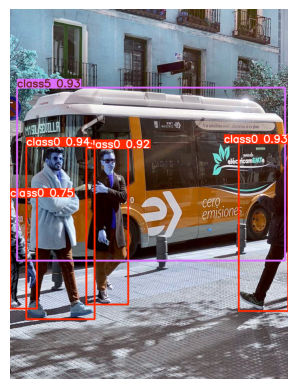

In [6]:
from ultralytics import ASSETS, YOLO
import matplotlib.pyplot as plt

# Load the ONNX model
model = YOLO("./temp/models/yolov7-ultralytics.onnx", task="detect")

# Run inference on the image
results = model(ASSETS / "bus.jpg")

# The `results` variable is a list of Results objects.
# We access the first item since we only processed a single image.
result = results[0]

# Plot the bounding boxes on the image.
# The plot() method returns a numpy array representing the annotated image.
annotated_frame = result.plot()

# Display the annotated image using Matplotlib
# plt.figure(figsize=(12, 10)) # Optional: Adjust the figure size for better viewing
plt.figure()
plt.imshow(annotated_frame)
plt.axis('off') # Hide the axis
plt.show()